In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import matplotlib.pyplot as plt

2026-03-02 10:19:39.283178: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772446779.479782      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772446779.535629      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_df1 = pd.read_csv("/kaggle/input/cyberbullying-tweets-dataset/cyber_bullying_data/train_data.csv")

test_df1 = pd.read_csv("/kaggle/input/cyberbullying-tweets-dataset/cyber_bullying_data/test_data.csv")


In [3]:
test_df = test_df1[test_df1['cyberbullying_type'] != 'not_cyberbullying']

In [4]:
train_df = train_df1[train_df1['cyberbullying_type'] != 'not_cyberbullying']

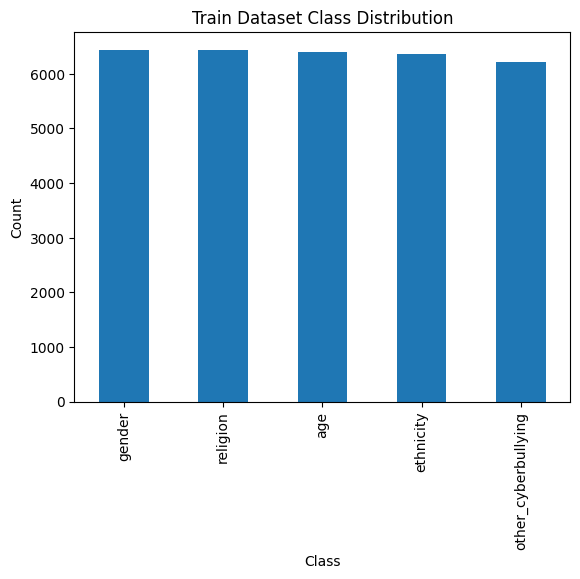

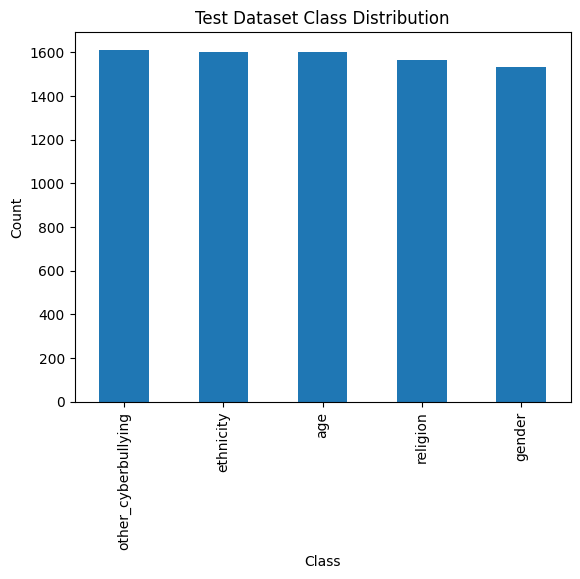

In [5]:
import matplotlib.pyplot as plt

for df, name in [(train_df, "Train"), (test_df, "Test")]:
    df["cyberbullying_type"].value_counts().plot(kind='bar', title=f"{name} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31832 entries, 0 to 38152
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          31832 non-null  object
 1   cyberbullying_type  31832 non-null  object
dtypes: object(2)
memory usage: 746.1+ KB


# Pre-Processing

In [7]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords if not already downloaded
nltk.download('stopwords')

def preprocess_text(text):
    """Cleans text by lowercasing, removing stopwords, and applying stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize and remove stopwords, apply stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    # Join words back into a string
    return " ".join(words)

train_df = train_df.copy()
test_df = test_df.copy()

# ✅ Use .loc to assign new column safely
train_df.loc[:, 'cleaned_text'] = train_df['tweet_text'].apply(preprocess_text)
test_df.loc[:, 'cleaned_text'] = test_df['tweet_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Encoding Catagorical variable

In [8]:
label_mapping = {
    "other_cyberbullying": 0,
    "religion": 1,
    "age": 2,
    "gender": 3,
    "ethnicity": 4
}

# Apply mapping
train_df["cyberbullying_encoded_type"] = train_df["cyberbullying_type"].map(label_mapping)
test_df["cyberbullying_encoded_type"] = test_df["cyberbullying_type"].map(label_mapping)


In [9]:

X_train, y_train,X_test,y_test= train_df['cleaned_text'], train_df['cyberbullying_encoded_type'],test_df['cleaned_text'], test_df['cyberbullying_encoded_type']


In [10]:

max_words = 46911
max_sequence_length = 35
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(pd.concat([train_df['cleaned_text'], test_df['cleaned_text']]))
X_train = tokenizer.texts_to_sequences(train_df['cleaned_text'])
X_test = tokenizer.texts_to_sequences(test_df['cleaned_text'])
X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)


In [11]:
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, Bidirectional, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

# GRU

In [12]:
# Define improved model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_sequence_length),  # Word embeddings

    GRU(256, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    LayerNormalization(),
    Dropout(0.3),

    GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    LayerNormalization(),
    Dropout(0.3),

    GRU(64, dropout=0.3, recurrent_dropout=0.2),
    LayerNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),     # 1st Dense layer
    Dropout(0.3),

    Dense(64, activation='relu'),      # 2nd Dense layer
    Dropout(0.3),

    Dense(32, activation='relu'),      # 3rd Dense layer
    Dropout(0.2),

    Dense(5, activation='softmax')     # Output layer for multi-class classification (6 classes)
])

# Compile with lower learning rate
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1772446805.991560      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [13]:
# Train model
early_stopping = EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=3,               # Number of epochs with no improvement before stopping
    restore_best_weights=True # Restore model weights from the best epoch
)

# Train model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 80s 238ms/step - accuracy: 0.4451 - loss: 1.2732 - val_accuracy: 0.9294 - val_loss: 0.2609
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 58s 233ms/step - accuracy: 0.9279 - loss: 0.2629 - val_accuracy: 0.9377 - val_loss: 0.2505
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 58s 233ms/step - accuracy: 0.9609 - loss: 0.1644 - val_accuracy: 0.9414 - val_loss: 0.2186
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.9712 - loss: 0.1200 - val_accuracy: 0.9430 - val_loss: 0.2437
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 58s 232ms/step - accuracy: 0.9800 - loss: 0.0879 - val_accuracy: 0.9395 - val_loss: 0.2431
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 58s 232ms/step - accuracy: 0.9815 - loss: 0.0793 - val_accuracy: 0.9399 - val_loss: 0.2420


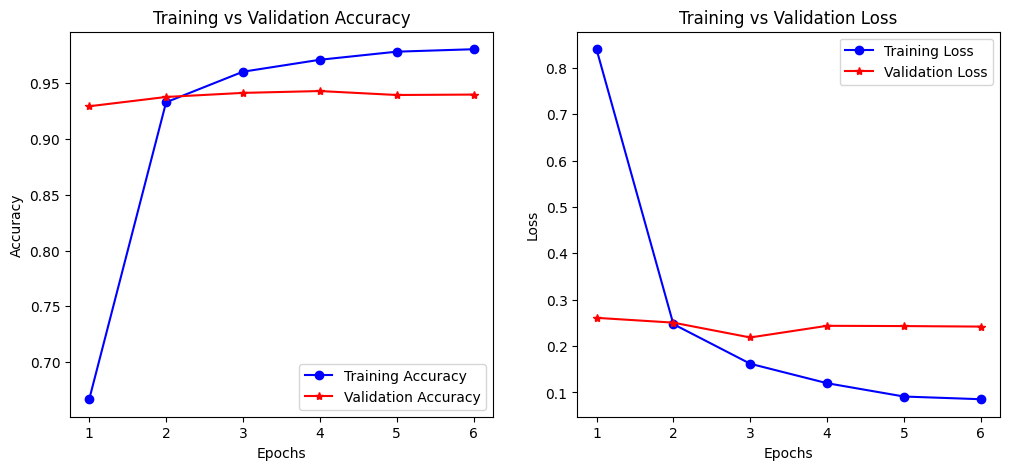

In [14]:
# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

248/248 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step
Classification Report:

                     precision    recall  f1-score   support

other_cyberbullying       0.88      0.87      0.88      1612
           religion       0.97      0.98      0.97      1566
                age       0.99      0.98      0.98      1603
             gender       0.90      0.90      0.90      1531
          ethnicity       0.97      0.98      0.97      1603

           accuracy                           0.94      7915
          macro avg       0.94      0.94      0.94      7915
       weighted avg       0.94      0.94      0.94      7915



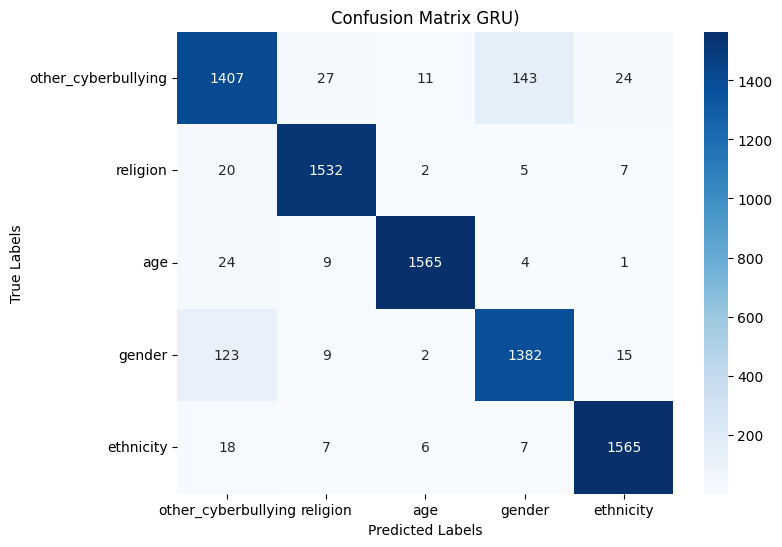

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names (for reports)
class_names = ['other_cyberbullying', 'religion', 'age', 'gender', 'ethnicity']

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix GRU)')
plt.show()


In [16]:
model.save("GRU_trained.h5")
print("Model saved as trained_model.h5")

Model saved as trained_model.h5
